In [394]:
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from matplotlib import colormaps

colors = ["#E69F00", "#56B4E9", "#009E73", "#D55E00", "#0072B2"]

from astropy.coordinates import SkyCoord, EarthLocation, solar_system_ephemeris, get_body_barycentric, get_body, AltAz
from astropy.time import Time, TimeDelta
from astropy import units as u

import glob
import os
from pathlib import Path

In [378]:
import json
# Helper function that will write each fit to the json file saving all fits.
def write_to_file(x_final, y_final, date, obj):
    out_loc = "fit_locs.json"
    bak_loc = "fit_locs_bak.json"
    if Path(out_loc).exists():
        with open(out_loc, "r") as f:
            data = json.load(f)
        with open(bak_loc, "w") as f:
            f.writelines(json.dumps(data))
    else:
        data = {}

    if date in data.keys():
        data[date].append([x_final, y_final, obj])
    else:
        data[date] = [[x_final, y_final, obj]]

    with open(out_loc, "w") as f:
        f.writelines(json.dumps(data))

In [187]:
# blindly assume that the image is centered
mid = np.array((im.shape[1] / 2, im.shape[0] / 2))
mid

array([4788., 3194.])

In [293]:
fnames = [Path(x).name for x in glob.glob("./*jpg")]


20260216124936 This is the first image that was saved in UTC, not mountain standard. Anything before this needs a shift.

In [440]:
def filename_to_time(fname, noshift=False):
    # At least with files in this format and 24 hour time the timestamp/filename
    # is a monotonically increasing integer.
    if (int(fname.replace(".jpg", "")) < 20260216124936) and not noshift:
        shift = TimeDelta(7 * u.hour)
    else:
        shift = 0
        
    year = fname[:4]
    month = fname[4:6]
    day = fname[6:8]

    hour = fname[8:10]
    minute = fname[10:12]
    second = fname[12:14]
    tstring = f"{year}-{month}-{day}T{hour}:{minute}:{second}"
    return Time(tstring, scale="utc") + shift

def load_image(fname):
    return np.array(Image.open(fname))

In [398]:
curr_file = fnames[2]
im = load_image(curr_file)
time = filename_to_time(curr_file)

In [399]:
loc = EarthLocation.of_site('kpno')
bodies = ["venus", "jupiter", "moon"]

In [400]:
aa_ref = AltAz(location=loc, obstime=time)
with solar_system_ephemeris.set('builtin'):
    for body in bodies:
        ob = get_body(body, time, loc)
        ob_altaz = ob.transform_to(aa_ref)

        print(f"{body}: {ob_altaz.alt.degree}, {ob_altaz.az.degree}")

venus: -69.52774242132348, 64.73040626155367
jupiter: 63.051061375652765, 256.0904550543998
moon: -35.43629588748826, 103.72147434726786


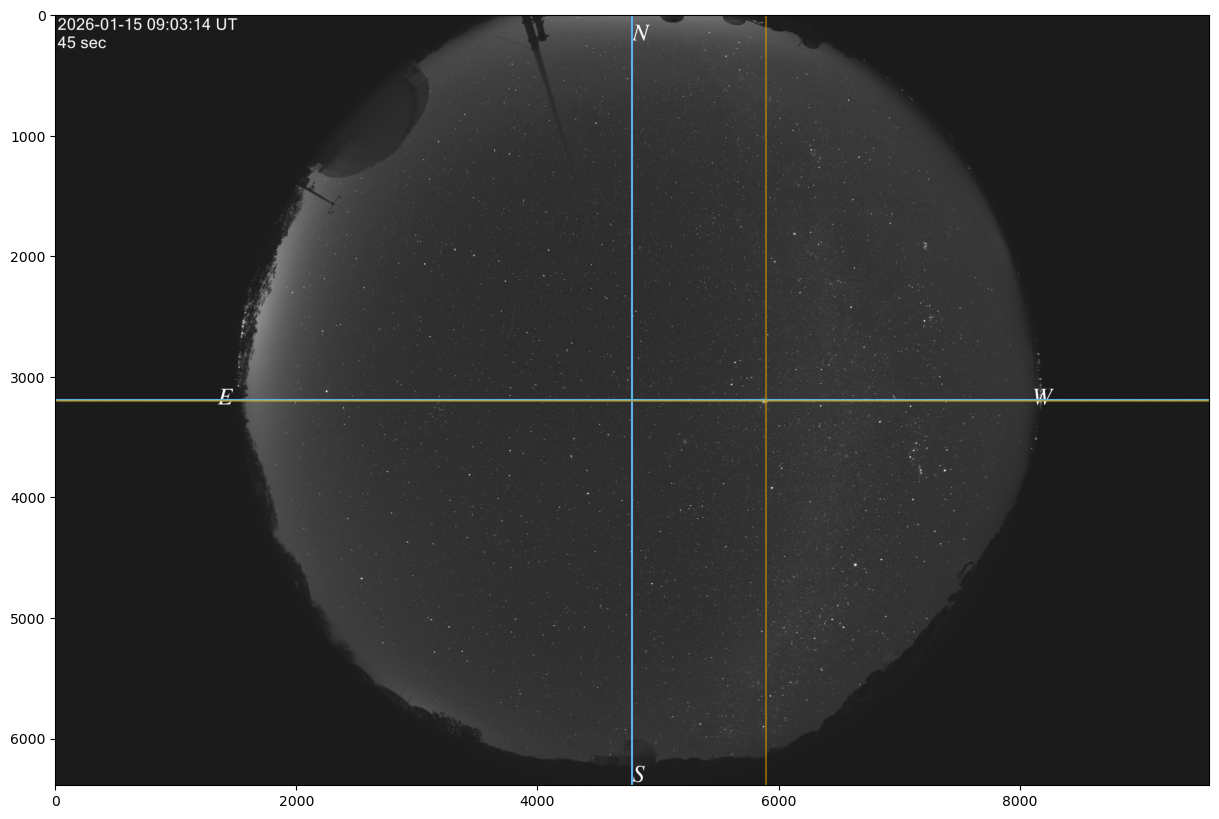

In [367]:
# Plot for getting a coarse estimate of the object's position.
fig, ax = plt.subplots(figsize=(20, 10))

ax.imshow(im, cmap="grey")

ax.axvline(mid[0], c=colors[1])
ax.axhline(mid[1], c=colors[1])

# The coarse guesses themselves.
x_p = 5900
y_p = 3200
ax.axvline(x_p, c=colors[0], alpha=0.5)
ax.axhline(y_p, c=colors[0], alpha=0.5)


In [368]:
def get_com_patch(im, x_guess, y_guess, width, thresh=False):
    patch = im[(y_guess - width // 2):(y_guess + width // 2), (x_guess - width // 2):(x_guess + width // 2)]

    if thresh:
        patch = patch > 200

    # xx, yy are vector positions from (0,0), which is the top left corner
    xx, yy = np.meshgrid(np.arange(width), np.arange(width))
    
    x_com = np.sum(xx * patch) / np.sum(patch)
    y_com = np.sum(yy * patch) / np.sum(patch)
    return [x_com, y_com]

In [369]:
width1 = 80
width2 = 60
x_thresh, y_thresh = get_com_patch(im, x_p, y_p, width1, True)

x_p2 = x_p - (width1 // 2) + int(x_thresh)
y_p2 = y_p - (width1 // 2) + int(y_thresh)

x_com2, y_com2 = get_com_patch(im, x_p2, y_p2, width2, False)

x_thresh, y_thresh, x_com2, y_com2

(np.float64(21.51298701298701),
 np.float64(43.496753246753244),
 np.float64(29.642085072189534),
 np.float64(29.727641117360914))

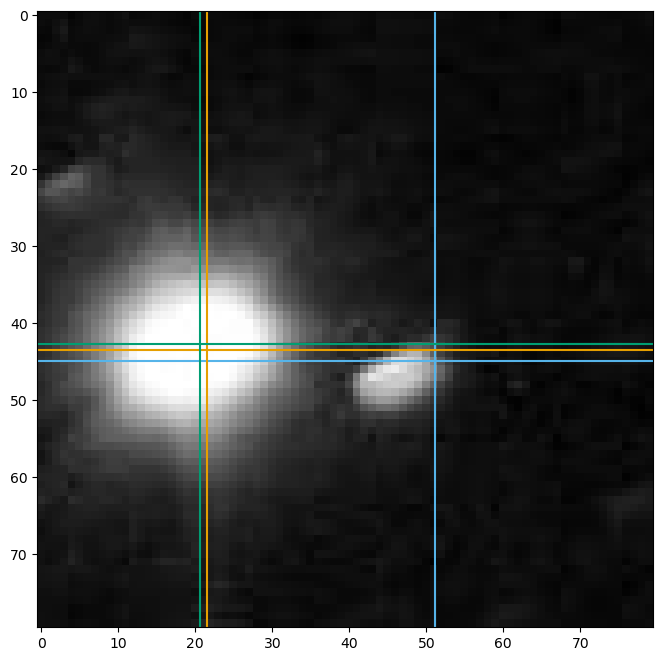

In [370]:
patch = im[(y_p - width1 // 2):(y_p + width1 // 2), (x_p - width1 // 2):(x_p + width1 // 2)]
delta_w = (width1 - width2) // 2
fig, ax = plt.subplots(figsize=(8,8))

ax.imshow(patch, cmap="grey")
ax.axhline(y_com, c=colors[1])
ax.axvline(x_com, c=colors[1])

ax.axhline(y_thresh, c=colors[0])
ax.axvline(x_thresh, c=colors[0])

# Need the coordinate converted from the original reference (edge of
# a window around p2, with a different width) to the current
# reference (around p1)
ax.axhline(y_com2 - (y_p - y_p2 - delta_w), c=colors[2])
ax.axvline(x_com2 - (x_p - x_p2 - delta_w), c=colors[2])


In [371]:
x_final = x_p2 - (width2 // 2) + x_com2
y_final = y_p2 - (width2 // 2) + y_com2

x_final, y_final

(np.float64(5880.64208507219), np.float64(3202.7276411173607))

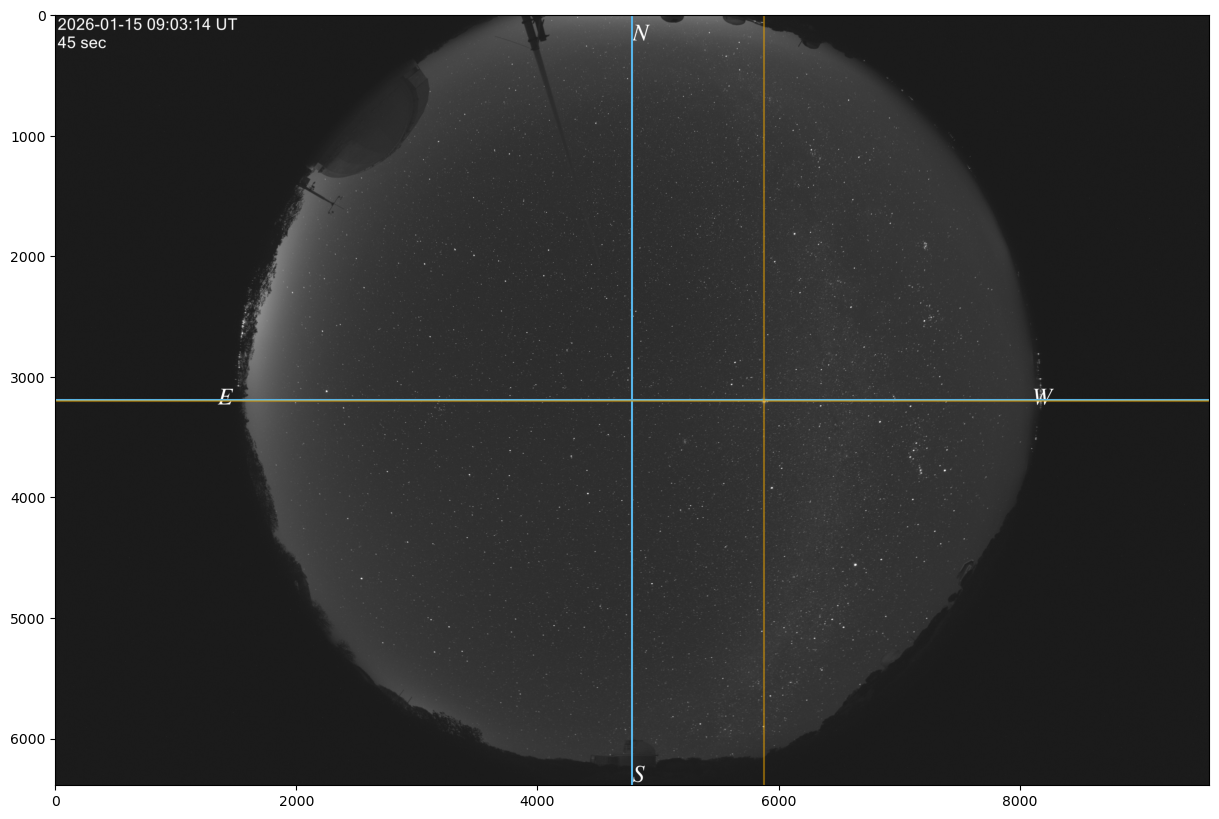

In [372]:
fig, ax = plt.subplots(figsize=(20, 10))

ax.imshow(im, cmap="grey")

ax.axvline(mid[0], c=colors[1])
ax.axhline(mid[1], c=colors[1])

ax.axvline(x_final, c=colors[0], alpha=0.5)
ax.axhline(y_final, c=colors[0], alpha=0.5)


In [402]:
curr_time = int(curr_file[:-4].replace(".jpg", ""))
if curr_time < 20260216124936:
    curr_time += 70000
curr_time = str(curr_time)
curr_time

'20260115090454'

In [380]:
write_to_file(x_final, y_final, curr_time, "jupiter")

In [448]:
out_loc = "fit_locs.json"

with open(out_loc, "r") as f:
   data = json.load(f)

all_rs = []
all_thetas = []
all_phis = []
phi_preds = []
for date in data.keys():
    xs, ys, objs = zip(*data[date])
    t = filename_to_time(date, noshift=True)

    xs = np.asarray(xs) - mid[0]
    ys = np.asarray(ys) - mid[1]
    rs = np.hypot(xs, ys)
    
    az = np.atan2(-xs, -ys)
    az = np.where(az < 0, az + 2 * np.pi, az) # [-pi, pi] -> [0, 2pi]

    aa_ref = AltAz(location=loc, obstime=t)
    
    thetas = []
    phis = []
    keep = []
    for body in objs:
        if body == "moon": 
            keep.append(False)
            continue
            
        aa = get_body(body, t, loc).transform_to(aa_ref)
        thetas.append(aa.alt.degree)
        phis.append(aa.az.degree)
        keep.append(True)
    print(keep)
    all_thetas.append(thetas)
    all_phis.append(phis)
    
    all_rs.append(rs[keep])
    phi_preds.append(az[keep])


all_rs = np.concatenate(all_rs)
all_thetas = np.deg2rad(90 - np.concatenate(all_thetas)) # Theta is altitude but I need it as zenith angle in radians.

all_phis = np.deg2rad(np.concatenate(all_phis))
phi_preds = np.concatenate(phi_preds)

[True, False]
[True]
[True, True]
[True]
[True, False]
[True, False]
[True]


In [450]:
funcs = {"equidistant": lambda x: x, "orthographic": lambda x: np.sin(x), "stereographic": lambda x: 2 * np.tan(x / 2), "equisolid": lambda x: 2 * np.sin(x / 2) }
reverse_funcs = {"equidistant": lambda x: x, "orthographic": lambda x: np.arcsin(x), "stereographic": lambda x: 2 * np.arctan(x / 2), "equisolid": lambda x: 2 * np.arcsin(x / 2) }

equidistant best fit scale 2156.2842043174205, R2=0.9981, image radius 3387.08
orthographic best fit scale 3045.6749558272236, R2=0.9673, image radius 3045.67
stereographic best fit scale 1777.31493818144, R2=0.9820, image radius 3554.63
equisolid best fit scale 2344.8937960384155, R2=0.9989, image radius 3316.18


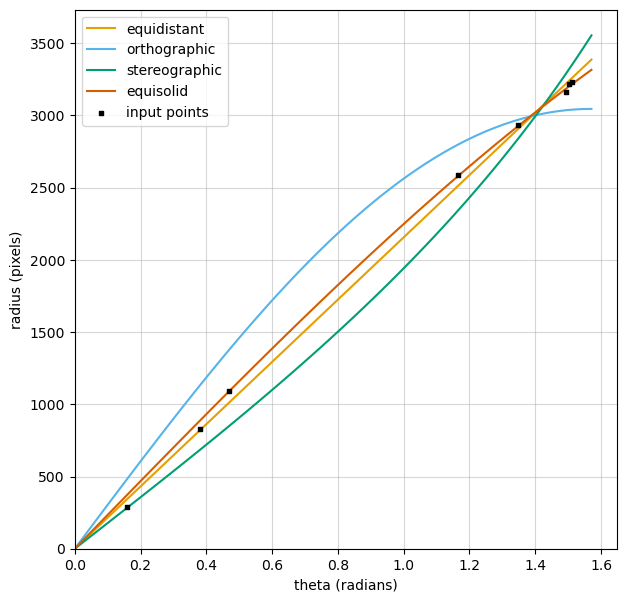

In [451]:
fig, ax = plt.subplots(figsize=(7, 7))

fits = {}
y_true = all_rs
theta_points = np.linspace(0, np.pi / 2, 60)
for i, (label, f) in enumerate(funcs.items()):
    y_pred = f(all_thetas)
    a = np.sum(y_true * y_pred) / np.sum(y_pred ** 2)
    y_pred = a * y_pred
    R2 = 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    
    # plt.plot(all_thetas, y_pred,  "-o", label=label)
    fits[label] = a
    y_points = a * f(theta_points)
    print(f"{label} best fit scale {a}, {R2=:.4f}, image radius {y_points[-1]:.2f}")
    plt.plot(theta_points, y_points, label=label, c=colors[i])

plt.scatter(all_thetas, all_rs, s=8, marker="s", label="input points", zorder=10, c="k")

ax.legend()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.set(ylabel="radius (pixels)", xlabel="theta (radians)", xlim=(0, xlim[-1]), ylim=(0, ylim[-1]))
ax.grid(alpha=0.5)

equidistant best fit scale 2156.2842043174205
orthographic best fit scale 3045.6749558272236
stereographic best fit scale 1777.31493818144
equisolid best fit scale 2344.8937960384155


/var/folders/4t/22tzk3s93vg_vqbncf_lj4ch0000gn/T/ipykernel_17468/970884582.py:2: RuntimeWarning: invalid value encountered in arcsin
  reverse_funcs = {"equidistant": lambda x: x, "orthographic": lambda x: np.arcsin(x), "stereographic": lambda x: 2 * np.arctan(x / 2), "equisolid": lambda x: 2 * np.arcsin(x / 2) }


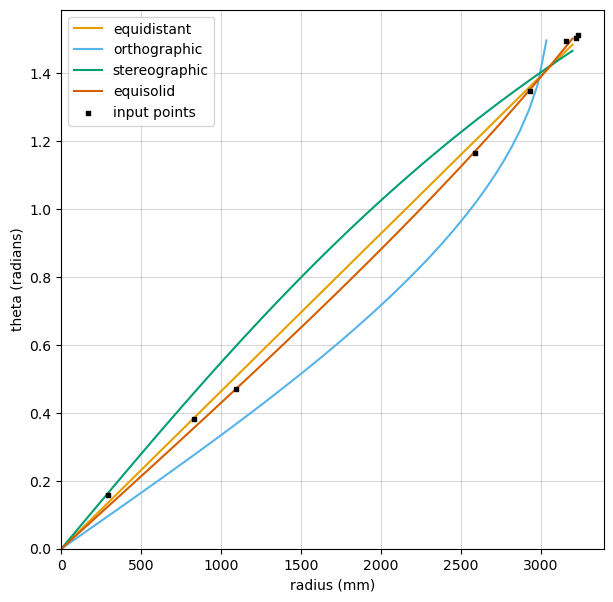

In [452]:
fig, ax = plt.subplots(figsize=(7, 7))

y_true = all_rs
r_points = np.linspace(0, 3200, 60)
for i, (label, f) in enumerate(reverse_funcs.items()):
    y_pred = funcs[label](all_thetas)
    a = np.sum(y_true * y_pred) / np.sum(y_pred ** 2)

    y_points = f(r_points / a) 
    print(f"{label} best fit scale {a}")
    plt.plot(r_points, y_points, label=label, c=colors[i])

plt.scatter(all_rs, all_thetas, s=8, marker="s", label="input points", zorder=10, c="k")

ax.legend()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.set(xlabel="radius (mm)", ylabel="theta (radians)", xlim=(0, xlim[-1]), ylim=(0, ylim[-1]))
ax.grid(alpha=0.5)

best fit offset b=0.1833 radians, 10.5031 degrees


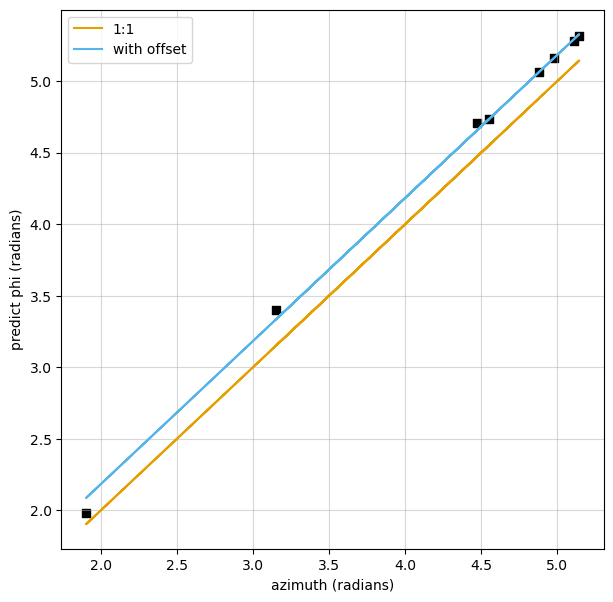

In [453]:
fig, ax = plt.subplots(figsize=(7, 7))

plt.scatter(all_phis, phi_preds, c="k", marker="s")
plt.plot(all_phis, all_phis, c=colors[0], label="1:1")

b = np.mean(phi_preds - all_phis)
print(f"best fit offset {b=:.4f} radians, {np.rad2deg(b):.4f} degrees")
plt.plot(all_phis, all_phis + b, c=colors[1], label="with offset")

ax.grid(alpha=0.5)
ax.set(xlabel="azimuth (radians)", ylabel="predict phi (radians)")
ax.legend()

In [454]:
fits["theta"] = b

In [455]:
with open("best_fit.json", "w") as f:
    f.writelines(json.dumps(fits))